### STUDENT HEALTH ANALYSIS PROJECT

In [2]:
## General Purpose
import warnings
from itertools import combinations
from copy import deepcopy

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("data/test.csv")
df

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295748,985836,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
295749,985837,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
295750,985838,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
295751,985839,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female


In [4]:
student_data = df.drop('id', axis=1).copy()
student_data.head(5)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [5]:
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   sleep_duration           263182 non-null  float64
 1   heart_rate               292396 non-null  float64
 2   bmi                      289797 non-null  float64
 3   calorie_expenditure      273101 non-null  float64
 4   step_count               289789 non-null  float64
 5   exercise_duration        292795 non-null  float64
 6   water_intake             277120 non-null  float64
 7   diet_type                292795 non-null  str    
 8   stress_level             260263 non-null  str    
 9   sleep_quality            270754 non-null  str    
 10  physical_activity_level  280058 non-null  str    
 11  smoking_alcohol          283504 non-null  str    
 12  gender                   286593 non-null  str    
dtypes: float64(7), str(6)
memory usage: 29.3 MB


In [6]:
student_data.shape

(295753, 13)

In [7]:
student_data.isna().sum() / len(student_data) * 100

sleep_duration             11.012906
heart_rate                  1.135069
bmi                         2.013843
calorie_expenditure         7.659094
step_count                  2.016548
exercise_duration           1.000159
water_intake                6.300190
diet_type                   1.000159
stress_level               11.999878
sleep_quality               8.452662
physical_activity_level     5.306793
smoking_alcohol             4.141632
gender                      3.097179
dtype: float64

##### Setting up outlier detection and cleaning 

In [8]:
# from pprint import pprint

# for col in student_data.select_dtypes(exclude=str):
#     mean = student_data[col].mean()
#     st_dev = student_data[col].std()
    
#     # Store clean floats in your dictionary
#     new_col[col] = float(mean), float(deviation)
    
#     ### Outlier definition
#     outlier_threasold =  st_dev * 3
#     print(f'--- {col} outlier ---')
#     print(outlier_threasold)
    
    
#     upper_limit = mean + outlier_threasold
#     lower_limit = mean - outlier_threasold
    
#     ## Getting outlier
#     outlier_numbers = (student_data[col] < lower_limit) | (student_data[col] > upper_limit)
#     print(f'Number of outliers found {outlier_numbers.sum()}\n')
    
# pprint(new_col)    
    

### Visualizing the outliers

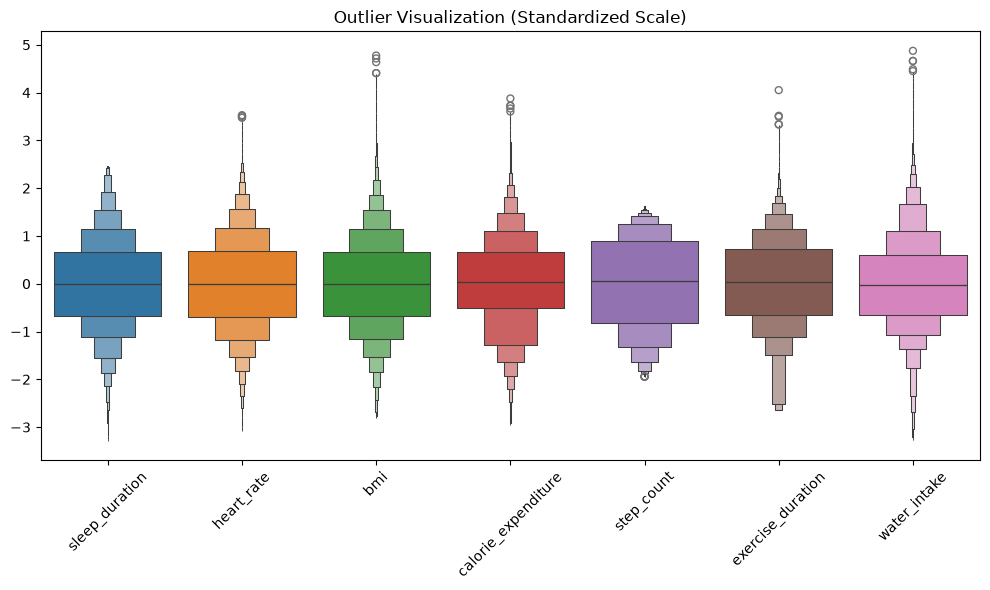

In [9]:
## Creating the boxplot
num_data = student_data.select_dtypes(exclude=str)

standardized_data = (num_data - num_data.mean() ) / num_data.std()


plt.figure(figsize=(10, 6))
sns.boxenplot(data=standardized_data)
plt.title("Outlier Visualization (Standardized Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

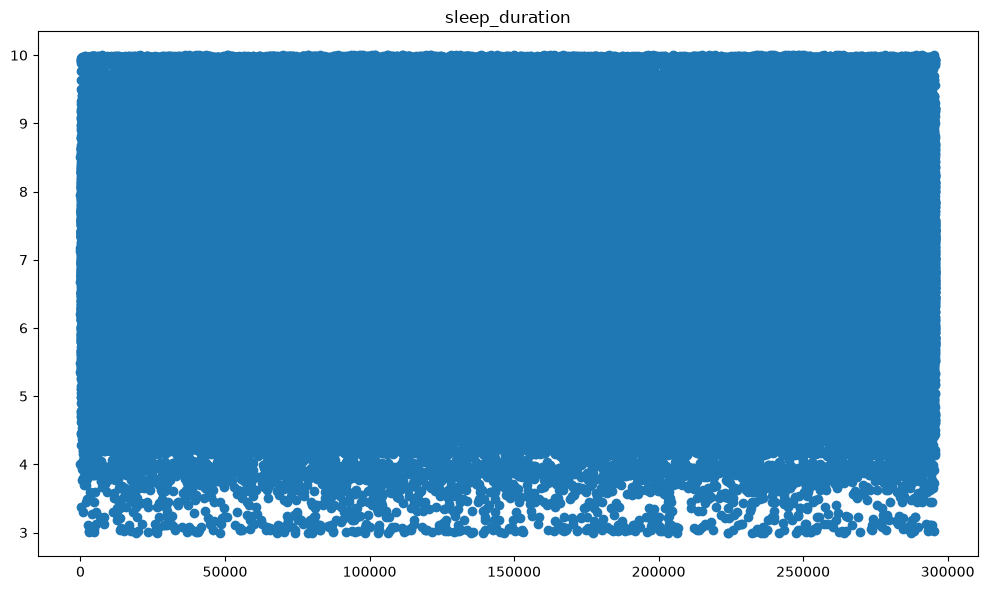

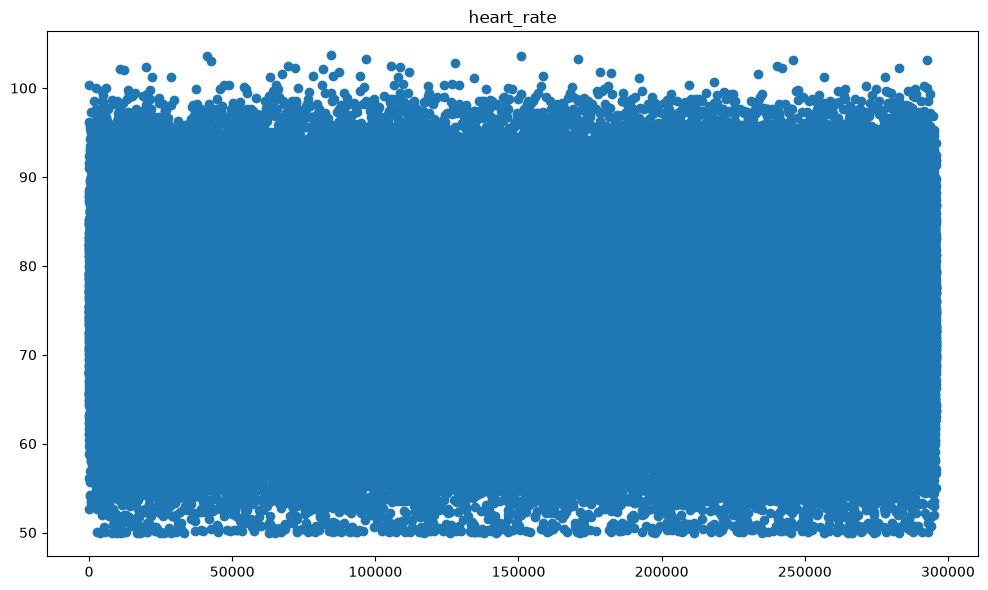

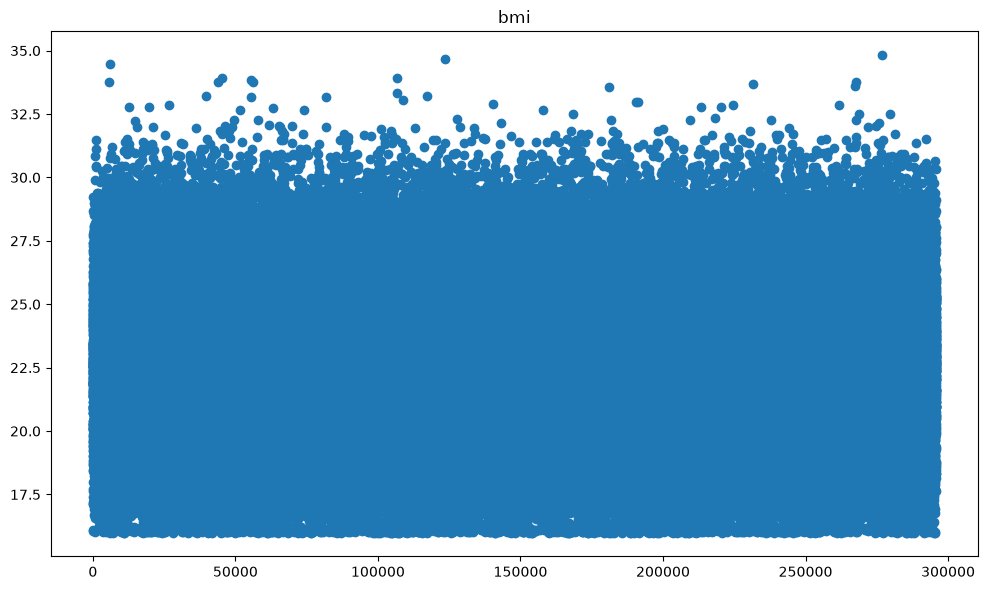

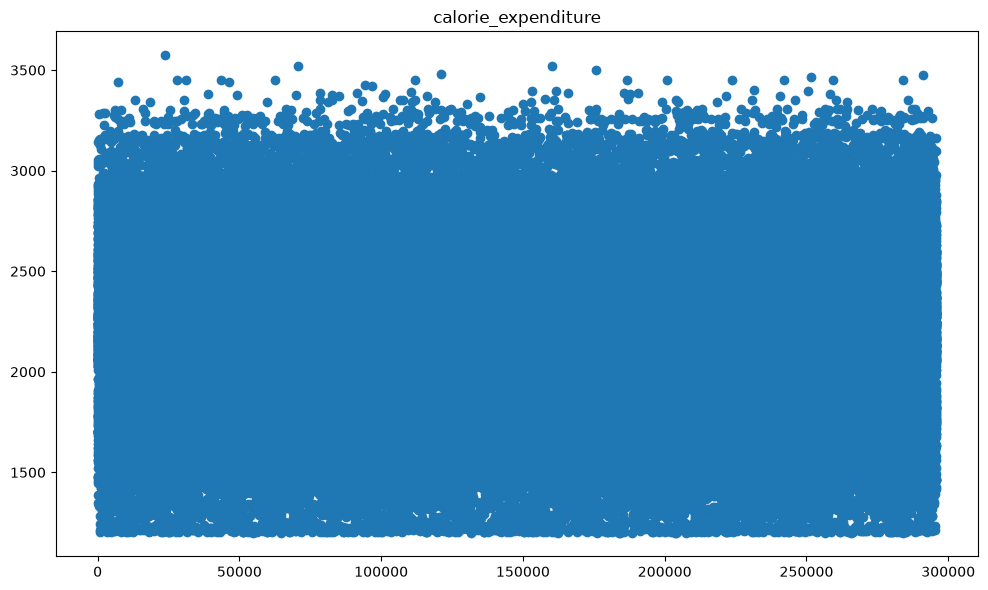

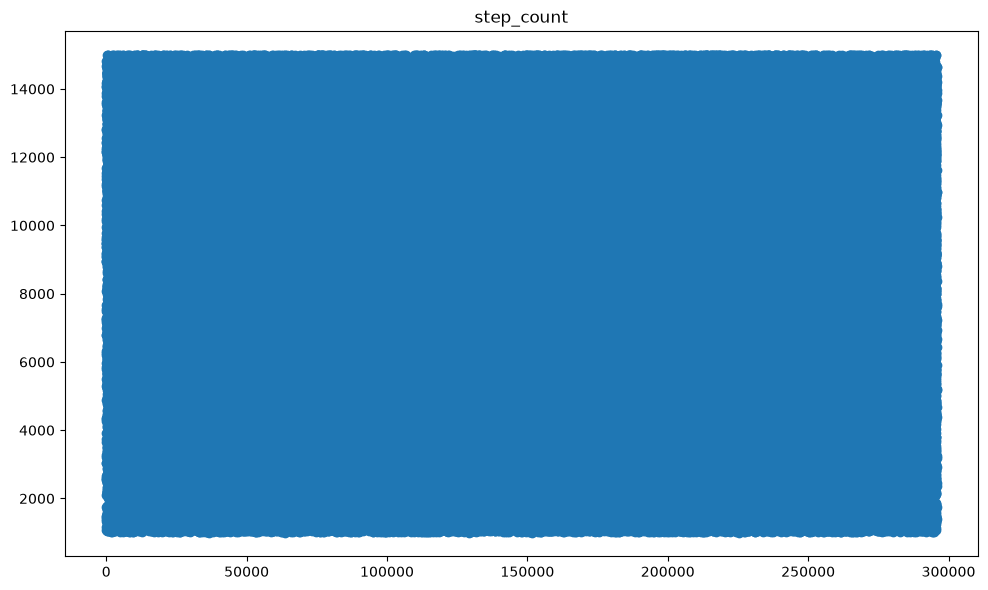

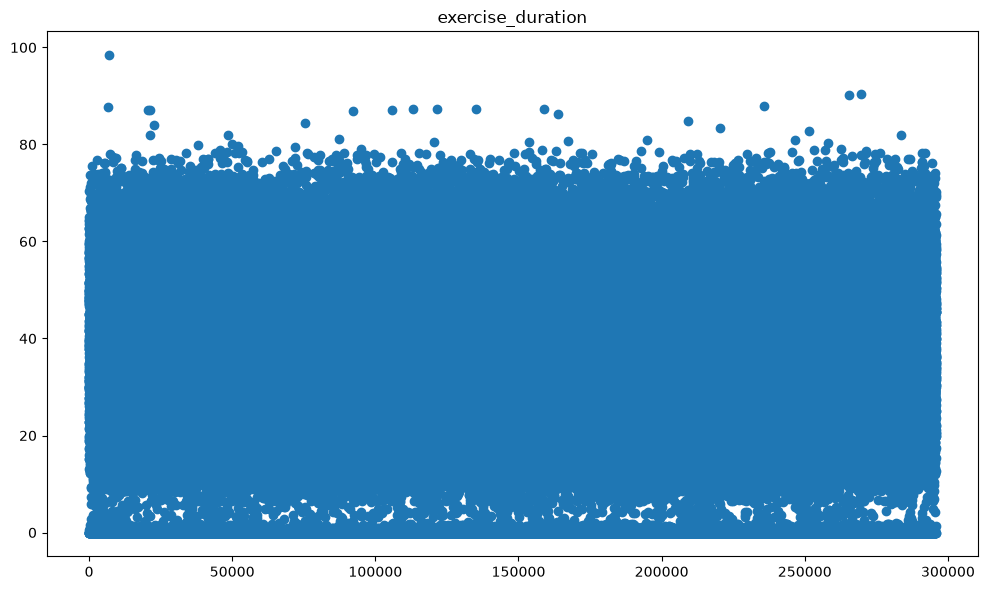

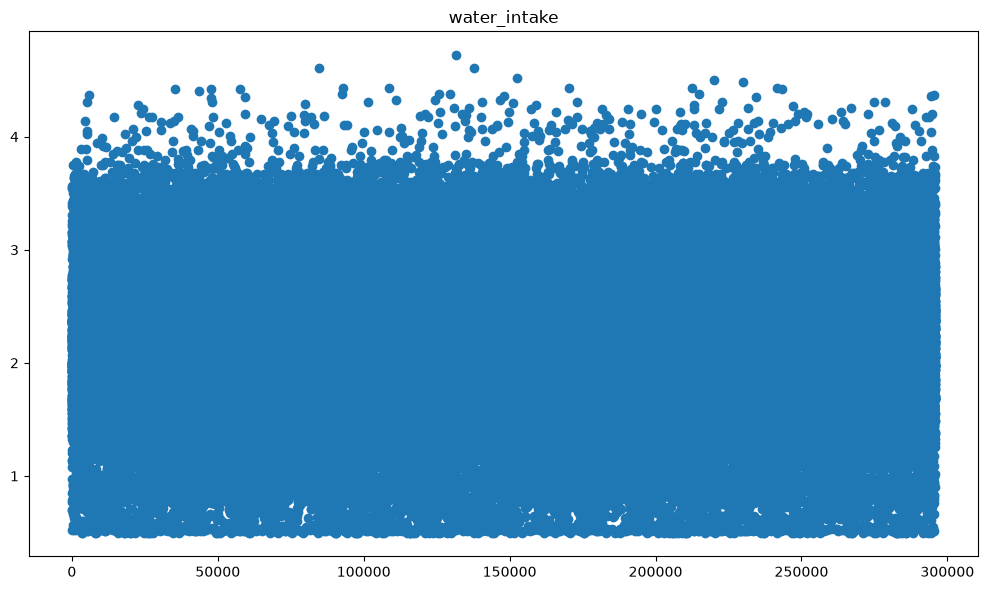

In [10]:
# Creating scatterplot

for col in num_data:
    plt.figure(figsize=(10, 6))
    plt.scatter(y=num_data[col], x=num_data.index)
    plt.title(f"{col}")
    plt.tight_layout()
    plt.show()

In [11]:

def outlier_remover(df):
    '''
    This calculates the stats of the data and remove the oulier
    using 3 standard deviation above and below the mean of the data
    '''
    data_outlier = {}
    data_stats = {}
    all_outlier_row = set()
    for col in df:
        
        ## Calculating the stats
        data_mean = df[col].mean()
        data_std = df[col].std()
        
        data_stats[col] = float(data_mean), float(data_std)
        
        ## Calculating outlier threasold
        outlier_threasold = data_std * 3
        
        ## Calculating the limit
        upper_limit = data_mean + outlier_threasold
        lower_limit = data_mean - outlier_threasold
        
        is_outlier = (df[col] < lower_limit) | (df[col] > upper_limit)
        outlier_row = df[is_outlier].index
        
        data_outlier[col] = float(is_outlier.sum())
        
        print("-------------------------------")
        print(outlier_row)
        
        all_outlier_row.update(outlier_row)
        
    ## Cleaning the dataset
    cleaned_data = df.drop(index=all_outlier_row)
    
    return cleaned_data, data_stats, data_outlier

In [12]:
cleaned_data, outlier_data, is_outlier =  outlier_remover(num_data)
outlier_data

-------------------------------
Index([   998,   2529,   2867,   2896,   4072,   4586,   4827,   5411,   5442,
         6592,
       ...
       288714, 288795, 289885, 292584, 293257, 293841, 293953, 294434, 294676,
       295348],
      dtype='int64', length=411)
-------------------------------
Index([   149,   2591,   2792,   3931,   4636,   5248,   5280,   5519,   5532,
         6054,
       ...
       288390, 288456, 288631, 289563, 290896, 291535, 292535, 292849, 292954,
       294047],
      dtype='int64', length=397)
-------------------------------
Index([   806,    969,   1038,   1057,   5725,   5874,   6031,   6439,   6734,
         7890,
       ...
       284635, 285523, 286404, 287889, 287933, 288740, 291588, 292421, 292433,
       295326],
      dtype='int64', length=490)
-------------------------------
Index([   560,   1723,   2622,   5874,   6182,   7182,   8081,  13186,  15822,
        16697,
       ...
       276372, 283101, 284019, 285750, 287329, 288439, 288839, 29039

{'sleep_duration': (6.993516843857103, 1.2163692716264922),
 'heart_rate': (75.07955956989835, 8.115118446383377),
 'bmi': (22.984661159363277, 2.4787083976009683),
 'calorie_expenditure': (2225.5149413586914, 347.81676091513486),
 'step_count': (8626.630524278009, 3924.64667683087),
 'exercise_duration': (38.796712375552865, 14.711180294016357),
 'water_intake': (2.1915079748845265, 0.5187708093419656)}

In [13]:
is_outlier

{'sleep_duration': 411.0,
 'heart_rate': 397.0,
 'bmi': 490.0,
 'calorie_expenditure': 177.0,
 'step_count': 0.0,
 'exercise_duration': 18.0,
 'water_intake': 1595.0}

In [14]:
cleaned_data

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
0,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86
1,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40
2,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76
3,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34
4,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45
...,...,...,...,...,...,...,...
295748,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17
295749,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98
295750,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18
295751,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02


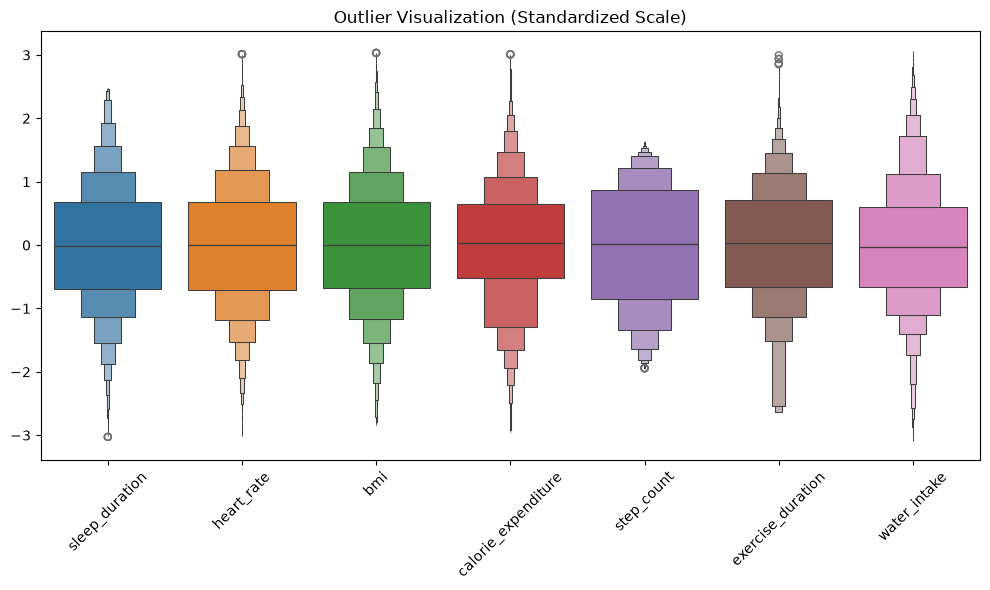

In [15]:
## Checking if outliers are gone 

## Standardizing data
standardized_cleaned_data = (cleaned_data - cleaned_data.mean()) / cleaned_data.std()

plt.figure(figsize=(10, 6))
sns.boxenplot(data=standardized_cleaned_data.dropna())
plt.title("Outlier Visualization (Standardized Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Check how many outliers remain
standardized = (cleaned_data - cleaned_data.mean()) / cleaned_data.std()
beyond_3std = (standardized.abs() > 3).sum()
print(beyond_3std)


sleep_duration          40
heart_rate              27
bmi                     19
calorie_expenditure     13
step_count               0
exercise_duration        0
water_intake           375
dtype: int64


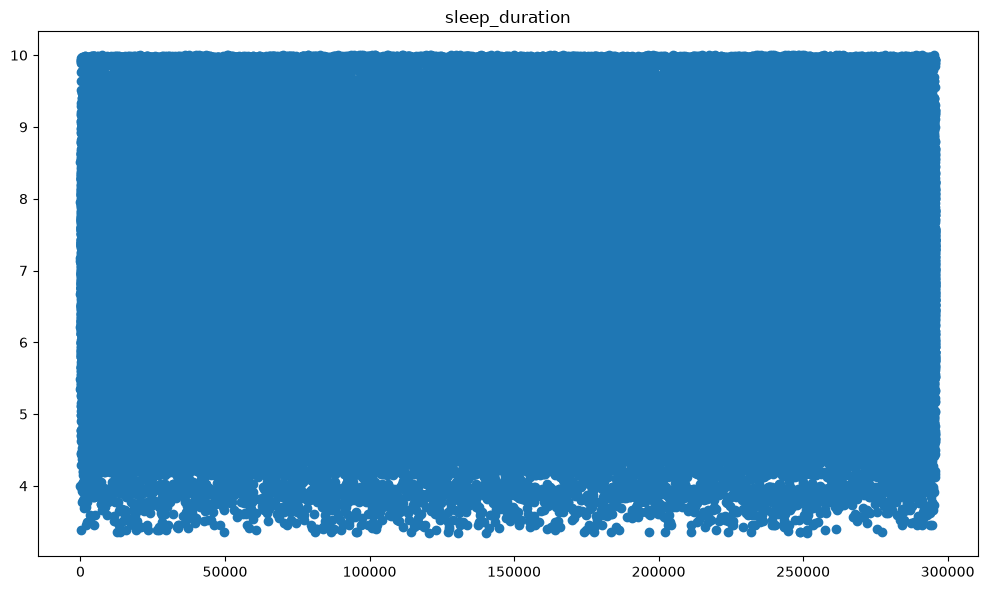

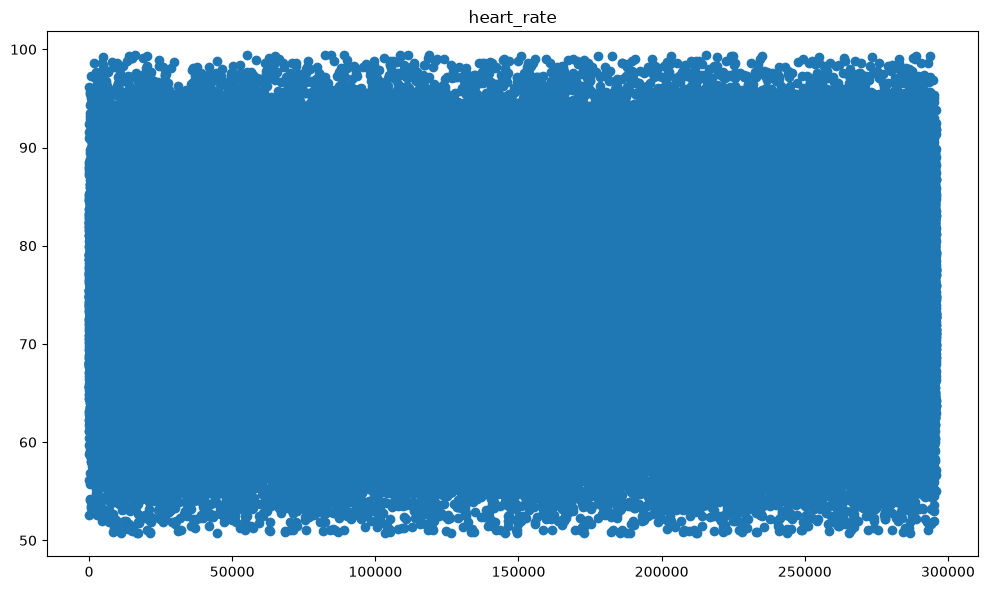

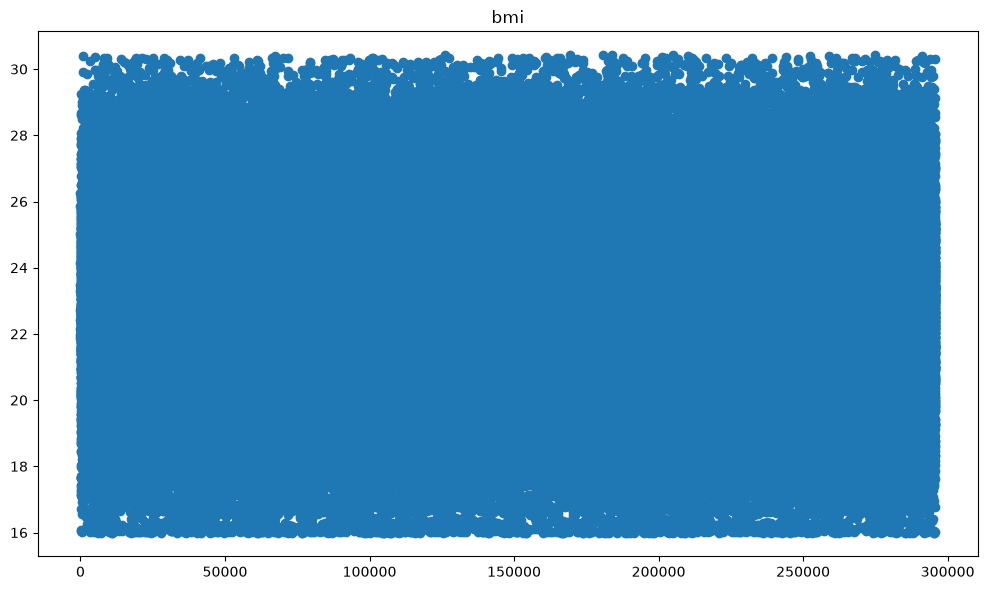

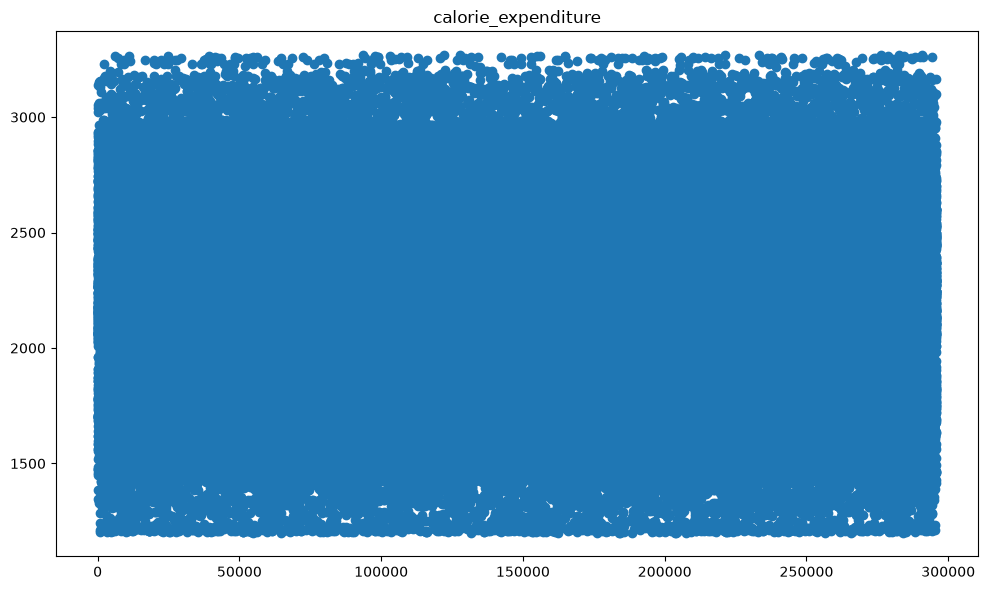

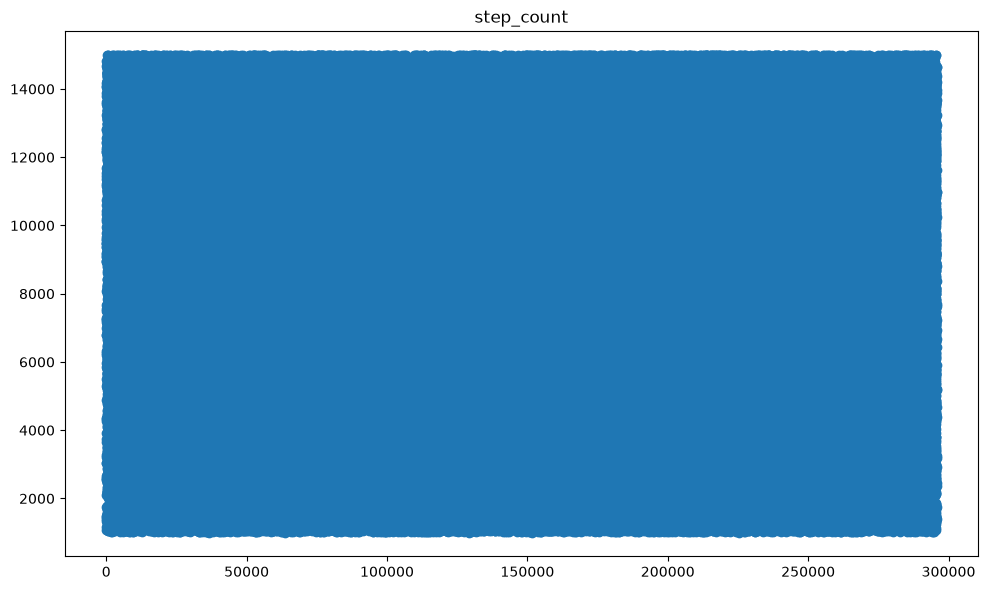

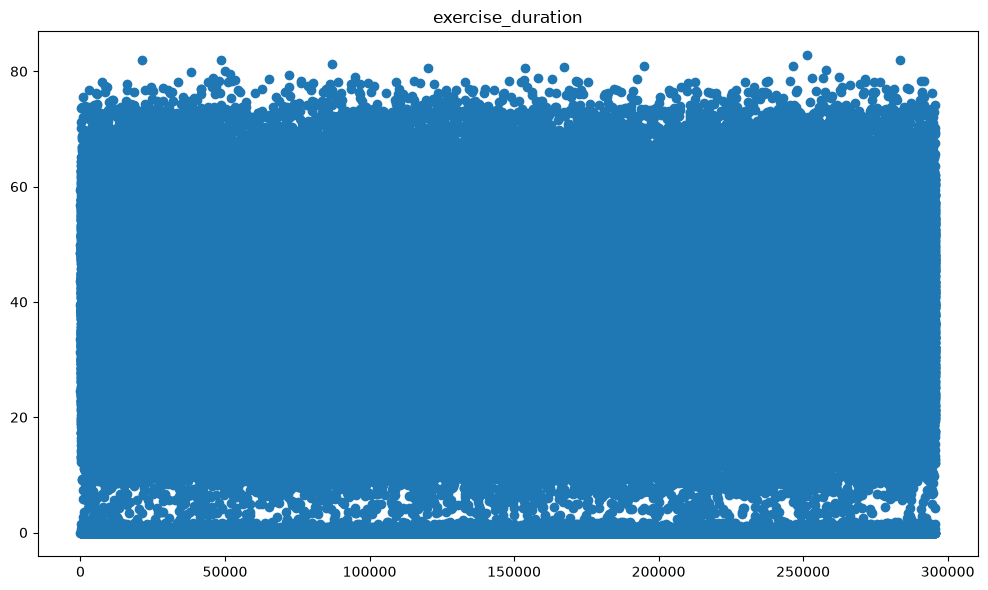

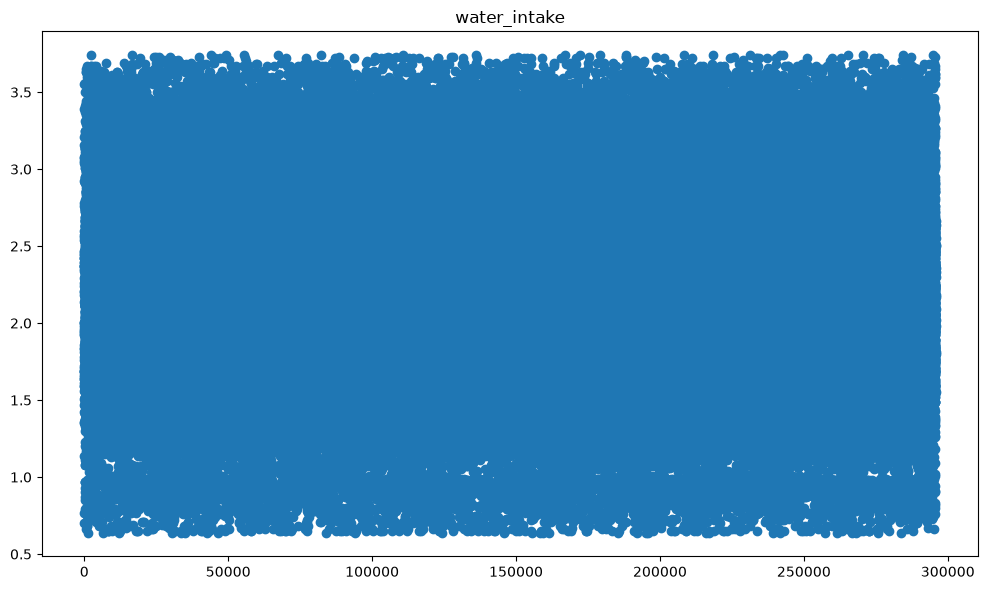

In [21]:

for col in cleaned_data:
    plt.figure(figsize=(10, 6))
    plt.scatter(x=cleaned_data.index, y=cleaned_data[col])
    plt.title(f"{col}")
    plt.tight_layout()
    plt.show()